# Real-material hysteresis on the loop-free HDiv-VIM

The HDiv-VIM (BDM1 FEEC charge-Gram) soft-iron demag solve is **loop-free** and
**symmetric positive-definite**, so a magnetostatic problem is one CG solve on a
chi-free H-matrix built once.  This notebook drives that solver with a **real
hysteresis material** in the *coupled* demag problem, using the constant-LHS
**Hantila polarization** iteration (`radia.vim.SolveHysteresis`): the charge
Gram is built once and every quasi-static step / nonlinear iteration reuses it.

Two results a synthetic toy model cannot demonstrate and a 0-D material law
cannot produce:

1. **Fidelity** -- on a low-demag rod the coupled $(H_{\rm int}, B)$ major loop
   reproduces the demag-free *intrinsic* material loop.  The demag only shears
   the applied field; the internal $(H,B)$ trace **is** the material law.
2. **Spatial iron loss** -- in a cube (flux non-uniform from demag) the
   per-element loop area $\oint H\cdot dB$ is a spatially-varying hysteresis-loss
   density that the loop-free solve resolves and integrates.

The material is a **K=40 Potter-Schmulian** play model (a literature analytical
hysteresis model) identified by `radia.hysteresis_io` and shipped in-repo as
`validation_test/hysteresis/binput_play_fixture.npz`.

In [1]:
import sys, json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt   # nbconvert supplies the inline backend -> figures embed as PNG

REPO = next(p for p in Path.cwd().resolve().parents if (p / "src" / "radia").exists())
sys.path.insert(0, str(REPO / "src"))
import ngsolve as ng
from ngsolve.meshes import MakeStructured3DMesh
import radia.vim as vim

MU0 = 4.0e-7 * np.pi
RHO_STEEL = 7650.0
FIX = REPO / "validation_test" / "hysteresis" / "binput_play_fixture.npz"

def load_play():
    d = np.load(FIX, allow_pickle=True)
    K = int(d["K"]); eta = np.asarray(d["eta"], float)
    tables = [(np.asarray(d[f"r_{k}"], float), np.asarray(d[f"f_{k}"], float)) for k in range(K)]
    return K, eta, tables

def loop_area(H, B):
    H = np.asarray(H, float); B = np.asarray(B, float)
    return 0.5 * float(abs(np.sum(H * np.roll(B, -1) - np.roll(H, -1) * B)))

K, eta, tables = load_play()
mat = vim.PlayHysteresisMaterial(K, eta, tables)
print(f"K = {K} play operators, threshold range 0..{eta.max():.2f} T, valid |B| <= {mat.b_max():.2f} T")

K = 40 play operators, threshold range 0..1.85 T, valid |B| <= 1.90 T


## The material

The virgin magnetization curve, coercivity and remanence, sampled directly from
the play model (no FEM).  This is a realistic, lossy, squarish material --
peak relative permeability $\sim 1400$, coercivity $\sim 480$ A/m.

peak mu_r ~ 1424  |  coercivity Hc ~ 469 A/m  |  remanence Br ~ 1.60 T
intrinsic major-loop loss (Bmax=1.6 T) = 2797 J/m^3 = 18.3 W/kg @ 50 Hz


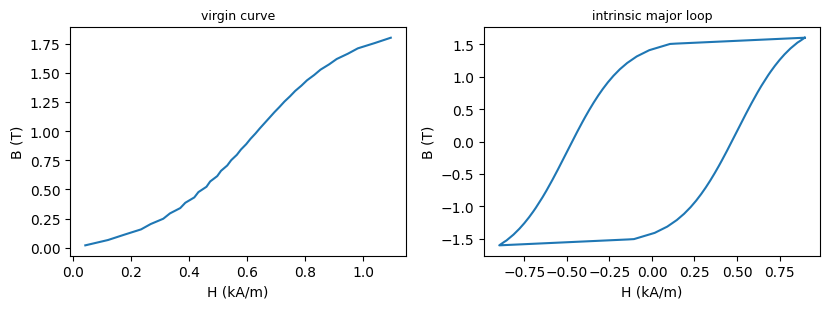

In [2]:
# virgin H(B)
s0 = mat.state0()
Bs = np.linspace(0.02, 1.8, 40); Bq = np.zeros((Bs.size, 3)); Bq[:, 2] = Bs
Hv = mat.forward(Bq, np.tile(s0[None, :], (Bs.size, 1)))[:, 2]
mur = Bs / (MU0 * Hv)

# intrinsic major loop (B sweep) -> Hc, Br, loss
def intrinsic_loop(Bmax, nseg=300):
    st = mat.state0()[None, :].copy()
    Bseq = np.concatenate([np.linspace(0, Bmax, nseg), np.linspace(Bmax, -Bmax, 2*nseg),
                           np.linspace(-Bmax, Bmax, 2*nseg)])
    H = []
    for bz in Bseq:
        B = np.array([[0., 0., bz]]); H.append(mat.forward(B, st)[0, 2]); st = mat.commit(B, st)
    return np.array(H)[nseg:], Bseq[nseg:]
Hc_loop, Bc_loop = intrinsic_loop(1.6)
Hc = abs(np.interp(0.0, Bc_loop[:600][::-1], Hc_loop[:600][::-1]))
Br = abs(np.interp(0.0, Hc_loop[:600], Bc_loop[:600]))
print(f"peak mu_r ~ {mur.max():.0f}  |  coercivity Hc ~ {Hc:.0f} A/m  |  remanence Br ~ {Br:.2f} T")
print(f"intrinsic major-loop loss (Bmax=1.6 T) = {loop_area(Hc_loop, Bc_loop):.0f} J/m^3 "
      f"= {loop_area(Hc_loop, Bc_loop)*50/RHO_STEEL:.1f} W/kg @ 50 Hz")

fig, ax = plt.subplots(1, 2, figsize=(8.4, 3.2))
ax[0].plot(Hv/1e3, Bs, "-"); ax[0].set_xlabel("H (kA/m)"); ax[0].set_ylabel("B (T)")
ax[0].set_title("virgin curve", fontsize=9)
ax[1].plot(Hc_loop/1e3, Bc_loop, "-"); ax[1].set_xlabel("H (kA/m)"); ax[1].set_ylabel("B (T)")
ax[1].set_title("intrinsic major loop", fontsize=9)
fig.tight_layout(); plt.show()

## (1) Fidelity: the coupled loop matches the intrinsic material loop

A low-demag rod ($0.1\times0.1\times1.0$, hex $2\times2\times16$) is driven through
a full major loop.  The demag shears the *applied* field, but the volume-averaged
internal $(H_z, B_z)$ trace lands on the demag-free intrinsic loop.

coupled peak B = 0.828 T, 7 max iters/step
coupled loss  = 989 J/m^3 = 6.46 W/kg @50Hz
0D intrinsic  = 1011 J/m^3   ->  loop-area agreement 2.21%


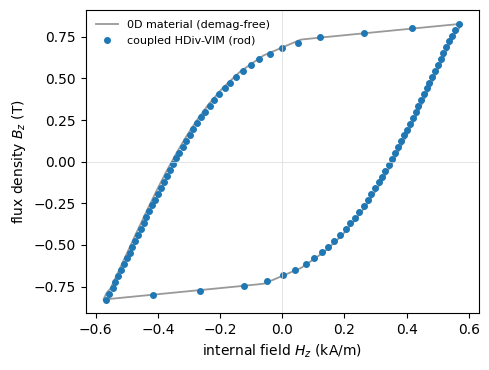

In [3]:
def rod(nz=16, a=0.1, aspect=10.0):
    L = aspect*a
    return MakeStructured3DMesh(hexes=True, nx=2, ny=2, nz=nz,
                                mapping=lambda x, y, z: (a*(x-0.5), a*(y-0.5), L*(z-0.5)))
def drive(H0, nb):
    up0 = np.linspace(0, H0, nb//2+1)[1:]; dn = np.linspace(H0, -H0, nb+1)[1:]
    up1 = np.linspace(-H0, H0, nb+1)[1:]; hz = np.concatenate([up0, dn, up1])
    h = np.zeros((hz.size, 3)); h[:, 2] = hz; return h, nb//2

h_steps, n0 = drive(16.0e3, 48)
with ng.TaskManager():
    res = vim.SolveHysteresis(rod(), h_steps, material=vim.PlayHysteresisMaterial(K, eta, tables))
Hz = np.array([s["H_avg"][2] for s in res["steps"]]); Bz = np.array([s["B_avg"][2] for s in res["steps"]])
peakB = float(np.abs(Bz).max()); area = loop_area(Hz[n0:], Bz[n0:])
Hi, Bi = intrinsic_loop(peakB); area0 = loop_area(Hi, Bi)
rel = abs(area-area0)/area0
print(f"coupled peak B = {peakB:.3f} T, {max(s['iters'] for s in res['steps'])} max iters/step")
print(f"coupled loss  = {area:.0f} J/m^3 = {area*50/RHO_STEEL:.2f} W/kg @50Hz")
print(f"0D intrinsic  = {area0:.0f} J/m^3   ->  loop-area agreement {100*rel:.2f}%")

fig, ax = plt.subplots(figsize=(5.0, 3.8))
ax.plot(Hi/1e3, Bi, "-", color="0.6", lw=1.3, label="0D material (demag-free)")
ax.plot(Hz[n0:]/1e3, Bz[n0:], "o", color="C0", ms=4, label="coupled HDiv-VIM (rod)")
ax.axhline(0, color="0.85", lw=0.5); ax.axvline(0, color="0.85", lw=0.5)
ax.set_xlabel("internal field $H_z$ (kA/m)"); ax.set_ylabel("flux density $B_z$ (T)")
ax.legend(frameon=False, fontsize=8); fig.tight_layout(); plt.show()
fidelity = dict(peakB_T=peakB, coupled_area=area, intrinsic_area=area0, rel=rel,
                loss_Wkg=area*50/RHO_STEEL, max_iters=int(max(s['iters'] for s in res['steps'])))

## (2) Spatial iron-loss map

In a cube the demag makes the flux non-uniform, so the per-element loop area
$\oint H\cdot dB$ varies in space.  The loop-free solve resolves the map and
integrates the total -- a 0-D material curve gives only a single number.

peak |B| = 1.347 T, 125 elements
loss density: min 519 / max 2110 J/m^3/cycle  (x4.06 spread)
total = 1261 J/cycle,  volume-average density 1261 J/m^3


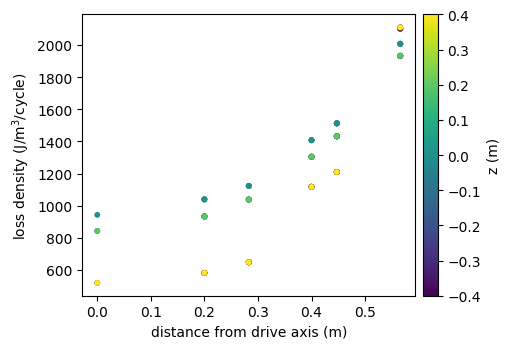

In [4]:
N = 5
h_steps, n0 = drive(2.0e5, 16)   # cube demag ~0.27 -> peak ~1.35 T, under b_max
with ng.TaskManager():
    mesh = MakeStructured3DMesh(hexes=True, nx=N, ny=N, nz=N,
                                mapping=lambda x, y, z: (x-0.5, y-0.5, z-0.5))
    res = vim.SolveHysteresis(mesh, h_steps, material=vim.PlayHysteresisMaterial(K, eta, tables))
    vol = np.asarray(ng.Integrate(ng.CoefficientFunction(1.0), mesh, element_wise=True), float)
    cx = np.asarray(ng.Integrate(ng.x, mesh, element_wise=True), float)/vol
    cy = np.asarray(ng.Integrate(ng.y, mesh, element_wise=True), float)/vol
    cz = np.asarray(ng.Integrate(ng.z, mesh, element_wise=True), float)/vol

steps = res["steps"][n0:]
Hseq = np.stack([np.asarray(s["H"], float) for s in steps])
Bseq = np.stack([np.asarray(s["B"], float) for s in steps])
dB = np.roll(Bseq, -1, 0) - Bseq; Hmid = 0.5*(Hseq + np.roll(Hseq, -1, 0))
loss_el = np.abs(np.sum(np.sum(Hmid*dB, axis=2), axis=0))
total = float(np.sum(loss_el*vol)); spread = float(loss_el.max()/loss_el.min())
print(f"peak |B| = {float(np.max(np.linalg.norm(Bseq.reshape(-1,3),axis=1))):.3f} T, {loss_el.size} elements")
print(f"loss density: min {loss_el.min():.0f} / max {loss_el.max():.0f} J/m^3/cycle  (x{spread:.2f} spread)")
print(f"total = {total:.0f} J/cycle,  volume-average density {total/np.sum(vol):.0f} J/m^3")

fig, ax = plt.subplots(figsize=(5.2, 3.6))
sc = ax.scatter(np.sqrt(cx**2+cy**2), loss_el, c=cz, cmap="viridis", s=18, edgecolors="none")
ax.set_xlabel("distance from drive axis (m)"); ax.set_ylabel("loss density (J/m$^3$/cycle)")
fig.colorbar(sc, ax=ax, pad=0.02, label="z (m)"); fig.tight_layout(); plt.show()
spatial = dict(peakB_T=float(np.max(np.linalg.norm(Bseq.reshape(-1,3),axis=1))),
               n_el=int(loss_el.size), loss_min=float(loss_el.min()), loss_max=float(loss_el.max()),
               spread=spread, total_J=total)

## (3) Robustness: out-of-domain fails loud

A play model carries no information beyond its identified extent `b_max`.  Driven
past it (here a deliberately huge step), the shape functions would extrapolate
and the demag-limited solve would run away -- so `SolveHysteresis` **raises**
instead of trusting an out-of-domain evaluation.

In [5]:
with ng.TaskManager():
    cube = MakeStructured3DMesh(hexes=True, nx=3, ny=3, nz=3,
                                mapping=lambda x, y, z: (x-0.5, y-0.5, z-0.5))
    try:
        vim.SolveHysteresis(cube, [[0.0, 0.0, 8.0e5]], material=vim.PlayHysteresisMaterial(K, eta, tables))
        print("NO GUARD -- this should not happen")
    except RuntimeError as e:
        print("guard fired as expected:\n ", str(e).split(" -- ")[0])

guard fired as expected:
  vim.SolveHysteresis: step 0 (H_ext=[     0.      0. 800000.]) drove |B|=4.522 T past the material's identified range b_max=1.900 T


## Summary

The loop-free HDiv-VIM runs a real hysteresis material in the coupled demag
solve: the coupled major loop reproduces the intrinsic material loop to a few
percent, the per-element loop area gives a spatially-resolved iron-loss map, and
out-of-domain drives fail loud.  The same duck-typed material protocol also
accepts the lab's vector stop model, so the demonstration is not tied to one
material family.